# 01: Why Before-After Fails

Core question: why is "the outcome changed after the policy"
not enough to estimate the policy effect?

We use an after-school tutoring program. Treated schools start
the program in 2026. Control schools do not. The outcome is the
average test score.


In [1]:
from lite_setup import ensure_packages
await ensure_packages()

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf

from checks import check_close, check_columns, check_same_estimate, check_sign
from did_utils import (
    did_2x2_table,
    manual_did,
    predicted_values_2x2,
    plot_group_trends,
    plot_did_counterfactual,
    make_event_dummies,
    extract_event_study_results,
    plot_event_study,
)


plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

DATA_DIR = Path("data")


Running outside JupyterLite; assuming packages are already installed.


In [2]:
group_df = pd.read_csv(DATA_DIR / "tutoring_2x2_group.csv")
group_df


,group,year,treated,post,mean_score
0,Control,2025,0,0,70.0
1,Control,2026,0,1,73.0
2,Treated,2025,1,0,75.0
3,Treated,2026,1,1,82.0


## Three comparisons

A before-after comparison uses only treated schools. A
cross-sectional comparison uses only the post period. DiD uses
both dimensions at once.

In a two-group, two-period design,

`DiD = (treated post - treated pre) - (control post - control pre)`.

The causal interpretation requires a counterfactual statement:
without tutoring, the treated schools would have changed by the
same amount as the control schools. This is the parallel trends
assumption in its simplest two-period form.


In [3]:
treated_pre = group_df.query("treated == 1 and post == 0")["mean_score"].iloc[0]
treated_post = group_df.query("treated == 1 and post == 1")["mean_score"].iloc[0]
control_pre = group_df.query("treated == 0 and post == 0")["mean_score"].iloc[0]
control_post = group_df.query("treated == 0 and post == 1")["mean_score"].iloc[0]

naive_before_after = treated_post - treated_pre
post_cross_section = treated_post - control_post
control_trend = control_post - control_pre
did_estimate = naive_before_after - control_trend
counterfactual_treated_post = treated_pre + control_trend

pd.Series(
    {
        "naive_before_after": naive_before_after,
        "post_cross_section": post_cross_section,
        "control_trend": control_trend,
        "counterfactual_treated_post": counterfactual_treated_post,
        "did_estimate": did_estimate,
    }
)


naive_before_after              7.0
post_cross_section              9.0
control_trend                   3.0
counterfactual_treated_post    78.0
did_estimate                    4.0
dtype: float64

In [4]:
print(check_close(did_estimate, 4.0, label="manual DiD estimate"))
print(check_close(counterfactual_treated_post, 78.0, label="treated post counterfactual"))


Correct: manual DiD estimate is approximately 4.
Correct: treated post counterfactual is approximately 78.


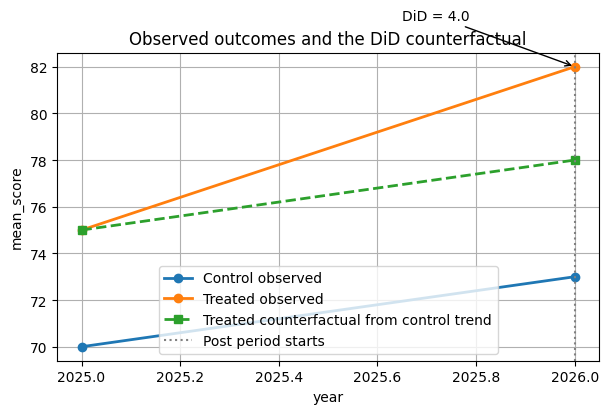

In [5]:
ax = plot_did_counterfactual(
    group_df,
    "mean_score",
    "year",
    treated_col="treated",
    post_col="post",
    title="Observed outcomes and the DiD counterfactual",
)
ax.annotate(
    f"DiD = {did_estimate:.1f}",
    xy=(2026, treated_post),
    xytext=(2025.65, treated_post + 2),
    arrowprops={"arrowstyle": "->"},
)
plt.show()


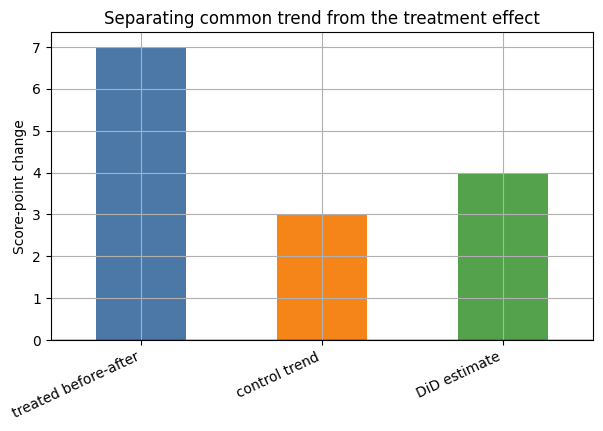

In [6]:
comparison = pd.Series(
    {
        "treated before-after": naive_before_after,
        "control trend": control_trend,
        "DiD estimate": did_estimate,
    }
)

ax = comparison.plot(kind="bar", color=["#4C78A8", "#F58518", "#54A24B"])
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Score-point change")
ax.set_title("Separating common trend from the treatment effect")
plt.xticks(rotation=25, ha="right")
plt.show()


## Checkpoint

In one or two sentences, explain why the treated group's
before-after change of 7 points is not the DiD estimate.

Takeaway: DiD does not compare only before vs after. It compares
before-after changes between treated and control groups.
